In [1]:
import os

import pandas as pd
import numpy as np
import itertools
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.transforms import ScaledTranslation

from utils import (_load_capacity, 
                   _load_dispatch, 
                   _group_capacity_technologies, 
                   _group_dispatch_technologies)

from utils import (_load_GHG_emissions, 
                   _load_clean_energy, 
                   _load_losses, 
                   _load_land_use, 
                   _load_cost, 
                   _group_emissions_by_zone, 
                   _group_clean_energy_by_zone, 
                   _group_land_use_by_zone, 
                   _group_cost_by_zone, 
                   _group_demand_by_zone)


from viz import (_plot_new_and_existing_capacity, 
                 _plot_new_and_existing_storage, 
                 _plot_dispatch, 
                 _plot_total_cost, 
                 _plot_average_cost, 
                 _plot_carbon_emissions, 
                 _plot_carbon_emissions_intesity, 
                 _plot_clean_energy, 
                 _plot_land_use, 
                 _plot_available_land)

plt.rcParams['legend.handlelength'] = 1
plt.rcParams['legend.handleheight'] = 1.125
plt.rcParams["font.family"] = "Avenir"

path_to_scenarios = '/Users/Guille/Desktop/india_power/scenarios'
path_to_images = '/Users/Guille/Desktop/india_power/images'
path_to_csvs = '/Users/Guille/Desktop/india_power/gridpath_india_viz/csvs'
path_to_tables = '/Users/Guille/Desktop/india_power/output_csvs'
path_to_input = '/Users/Guille/Desktop/india_power/input_data/'

In [2]:
def _save_group_csv(df_1_, df_2_, load_zones_, path, file_name):
    
    df_ = df_1_.copy()

    for scenario, label in zip(df_2_['scenario'], df_2_['label']):
        df_.loc[df_['scenario'] == scenario, 'scenario'] = label

    df_ = pd.merge(df_, load_zones_, 
                   on  = 'load_zone', 
                   how = 'inner')

    df_.to_csv(path + '/' + file_name, index = False)

def _save_summary_csv(df_, path, file_name):
    df_['system_cost'].to_csv(path + '/' + file_name.format('system_cost'), index = False)
    df_['emissions'].to_csv(path + '/' + file_name.format('emissions'), index = False)
    df_['clean_energy'].to_csv(path + '/' + file_name.format('clean_energy'), index = False)
    
tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 
load_zones_  = pd.read_csv(path_to_input + r"/load_zones.csv").drop(columns = ['state', 'rps_zone'])

In [3]:
scen_group = 'additional_1'

df_1_ = {}
df_2_ = {}

df_1_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

df_1_['capacity'] = _load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = _load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = _group_capacity_technologies(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = _group_dispatch_technologies(df_1_['dispatch'], tech_labels_)

emission_      = _load_GHG_emissions(df_2_['scen_labels'])
cost_, demand_ = _load_cost(df_2_['scen_labels'])
clean_         = _load_clean_energy(df_2_['scen_labels'])

df_2_['emissions']                    = _group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = _group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
df_2_['clean_energy']                 = _group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capcity exogeously
df_2_['system_cost']['fixed_cost'] += 5.79e9

# Save processed results in csv files
_save_group_csv(df_1_['capacity'], df_1_['scen_labels'], load_zones_, path_to_tables, 
                file_name = f'{scen_group}-grouped_capacity.csv')

_save_group_csv(df_1_['dispatch'], df_1_['scen_labels'], load_zones_, path_to_tables, 
                file_name = f'{scen_group}-grouped_dispatch.csv')

_save_summary_csv(df_2_, path_to_tables, 
                  file_name = f'{scen_group}' + '-{}.csv')

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/pier
VREhigh_SThigh_CONVhigh_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/cost
VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/additional


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize = 20, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

df_2_['scen_labels']['marker'] = None

_plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                ylabel = 'Existing & New Capacity (GW)',
                                legend = False,
                                y_lim_max = 4500,
                                y_grid_inc = 500)

_plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                               ylabel = 'Existing & New Storage Capacity (GWh)', 
                               legend = False,
                               y_lim_max = 4500,
                               y_grid_inc = 500)

# Plot average cost of electricity for different scenarios
_plot_average_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                   y_min = 35,
                   y_max = 70,
                   legend = False)

# Plot GHG emissions for different scenarios
_plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                       y_min = 0,
                       y_max = 1400,
                       legend = False)

leg = _ax['D'].legend(title = 'Scenarios (from left to right)',
                      handlelength = 1.75,
                      loc = (-7., -0.8),
                      frameon = False,
                      title_fontsize = 20,
                      prop = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-additional_1-capacity_summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/SI-additional_1-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

In [ ]:
scen_group = 'additional_2'

df_1_ = {}
df_2_ = {}

df_1_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

df_1_['capacity'] = _load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = _load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = _group_capacity_technologies(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = _group_dispatch_technologies(df_1_['dispatch'], tech_labels_)

emission_      = _load_GHG_emissions(df_2_['scen_labels'])
cost_, demand_ = _load_cost(df_2_['scen_labels'])
clean_         = _load_clean_energy(df_2_['scen_labels'])

df_2_['emissions']                    = _group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = _group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
df_2_['clean_energy']                 = _group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capacity exogenously
df_2_['system_cost']['fixed_cost'] += 5.79e9

# Save processed results in csv files
_save_group_csv(df_1_['capacity'], df_1_['scen_labels'], load_zones_, path_to_tables, 
                file_name = f'{scen_group}-grouped_capacity.csv')

_save_group_csv(df_1_['dispatch'], df_1_['scen_labels'], load_zones_, path_to_tables, 
                file_name = f'{scen_group}-grouped_dispatch.csv')

_save_summary_csv(df_2_, path_to_tables, 
                  file_name = f'{scen_group}' + '-{}.csv')

In [ ]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize = 20, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

df_2_['scen_labels']['marker'] = None

_plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                ylabel = 'Existing & New Capacity (GW)',
                                legend = False,
                                y_lim_max = 4500,
                                y_grid_inc = 500)

_plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                               ylabel = 'Existing & New Storage Capacity (GWh)', 
                               legend = False,
                               y_lim_max = 4500,
                               y_grid_inc = 500)

# Plot the average cost of electricity for different scenarios
_plot_average_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                   y_min = 35,
                   y_max = 70,
                   legend = False)

# Plot GHG emissions for different scenarios
_plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                       y_min = 0,
                       y_max = 1400,
                       legend = False)

leg = _ax['D'].legend(title = 'Scenarios (from left to right)',
                      handlelength = 1.75,
                      loc = (-7., -0.5),
                      frameon = False,
                      title_fontsize = 20,
                      prop = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-additional_2-capacity_summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/SI-additional_2-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

In [ ]:
scen_group = 'additional_3'

df_1_ = {}
df_2_ = {}

df_1_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

df_1_['capacity'] = _load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = _load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = _group_capacity_technologies(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = _group_dispatch_technologies(df_1_['dispatch'], tech_labels_)

emission_      = _load_GHG_emissions(df_2_['scen_labels'])
cost_, demand_ = _load_cost(df_2_['scen_labels'])
clean_         = _load_clean_energy(df_2_['scen_labels'])

df_2_['emissions']                    = _group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = _group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
df_2_['clean_energy']                 = _group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capacity exogenously
df_2_['system_cost']['fixed_cost'] += 5.79e9

# Save processed results in CSV files
_save_group_csv(df_1_['capacity'], df_1_['scen_labels'], load_zones_, path_to_tables, 
                file_name = f'{scen_group}-grouped_capacity.csv')

_save_group_csv(df_1_['dispatch'], df_1_['scen_labels'], load_zones_, path_to_tables, 
                file_name = f'{scen_group}-grouped_dispatch.csv')

_save_summary_csv(df_2_, path_to_tables, 
                  file_name = f'{scen_group}' + '-{}.csv')

In [ ]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize = 20, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

df_2_['scen_labels']['marker'] = None

_plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                ylabel = 'Existing & New Capacity (GW)',
                                legend = False,
                                y_lim_max = 4500,
                                y_grid_inc = 500)

_plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                               ylabel = 'Existing & New Storage Capacity (GWh)', 
                               legend = False,
                               y_lim_max = 4500,
                               y_grid_inc = 500)

# Plot the average cost of electricity for different scenarios
_plot_average_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                   y_min = 35,
                   y_max = 70,
                   legend = False)

# Plot GHG emissions for different scenarios
_plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                       y_min = 0,
                       y_max = 1400,
                       legend = False)

leg = _ax['D'].legend(title = 'Scenarios (from left to right)',
                      handlelength = 1.75,
                      loc = (-7., -0.5),
                      frameon = False,
                      title_fontsize = 20,
                      prop = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-additional_3-capacity_summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/SI-additional_3-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

In [ ]:
scen_group = 'additional_4'

df_1_ = {}
df_2_ = {}

df_1_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

df_1_['capacity'] = _load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = _load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = _group_capacity_technologies(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = _group_dispatch_technologies(df_1_['dispatch'], tech_labels_)

emission_      = _load_GHG_emissions(df_2_['scen_labels'])
cost_, demand_ = _load_cost(df_2_['scen_labels'])
clean_         = _load_clean_energy(df_2_['scen_labels'])

df_2_['emissions']                    = _group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = _group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
df_2_['clean_energy']                 = _group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capcity exogeously
df_2_['system_cost']['fixed_cost'] += 5.79e9

# Save processed results in csv files
_save_group_csv(df_1_['capacity'], df_1_['scen_labels'], load_zones_, path_to_tables, 
                file_name = f'{scen_group}-grouped_capacity.csv')

_save_group_csv(df_1_['dispatch'], df_1_['scen_labels'], load_zones_, path_to_tables, 
                file_name = f'{scen_group}-grouped_dispatch.csv')

_save_summary_csv(df_2_, path_to_tables, 
                  file_name = f'{scen_group}' + '-{}.csv')

In [ ]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize  = 20, 
            weight    = "bold",
            va        = 'bottom',
            family    = 'Arial')

df_2_['scen_labels']['marker'] = None

_plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                ylabel     = 'Existing & New Capacity (GW)',
                                legend     = False,
                                y_lim_max  = 4500,
                                y_grid_inc = 500)

_plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                               ylabel     = 'Existing & New Storage Capacity (GWh)', 
                               legend     = False,
                               y_lim_max  = 4500,
                               y_grid_inc = 500)

# Plot average cost of electricity for different scenarios
_plot_average_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                   y_min  = 35,
                   y_max  = 70,
                   legend = False)

# Plot GHG emissions for different scenarios
_plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                       y_min  = 0,
                       y_max  = 1400,
                       legend = False)

leg = _ax['D'].legend(title          = 'Scenarios (from left to right)',
                      handlelength   = 1.75,
                      loc            = (-7., -0.5),
                      frameon        = False,
                      title_fontsize = 20,
                      prop           = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-additional_4-capacity_summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/SI-additional_4-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [23]:
scen_group = 'additional_5'

df_1_ = {}
df_2_ = {}

df_1_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

df_1_['capacity'] = _load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = _load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = _group_capacity_technologies(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = _group_dispatch_technologies(df_1_['dispatch'], tech_labels_)

emission_      = _load_GHG_emissions(df_2_['scen_labels'])
cost_, demand_ = _load_cost(df_2_['scen_labels'])
clean_         = _load_clean_energy(df_2_['scen_labels'])

df_2_['emissions']                    = _group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = _group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
df_2_['clean_energy']                 = _group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capcity exogeously
df_2_['system_cost']['fixed_cost'] += 5.79e9

# Save processed results in csv files
_save_group_csv(df_1_['capacity'], df_1_['scen_labels'], load_zones_, path_to_tables, 
                file_name = f'{scen_group}-grouped_capacity.csv')

_save_group_csv(df_1_['dispatch'], df_1_['scen_labels'], load_zones_, path_to_tables, 
                file_name = f'{scen_group}-grouped_dispatch.csv')

_save_summary_csv(df_2_, path_to_tables, file_name = f'{scen_group}' + '-{}.csv')

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVmid_H2_NoNewGas_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_NoNewGas_NoCoalPipeline_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_NoNewGas_NoCoalPipepile_NoNewCoal_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVmid_H2_NoNewGas_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_NoNewGas_NoCoalPipeline_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_NoNewGas_NoCoalPipepile_NoNewCoal_RES_8PRM_CC_50RPS_90CAP

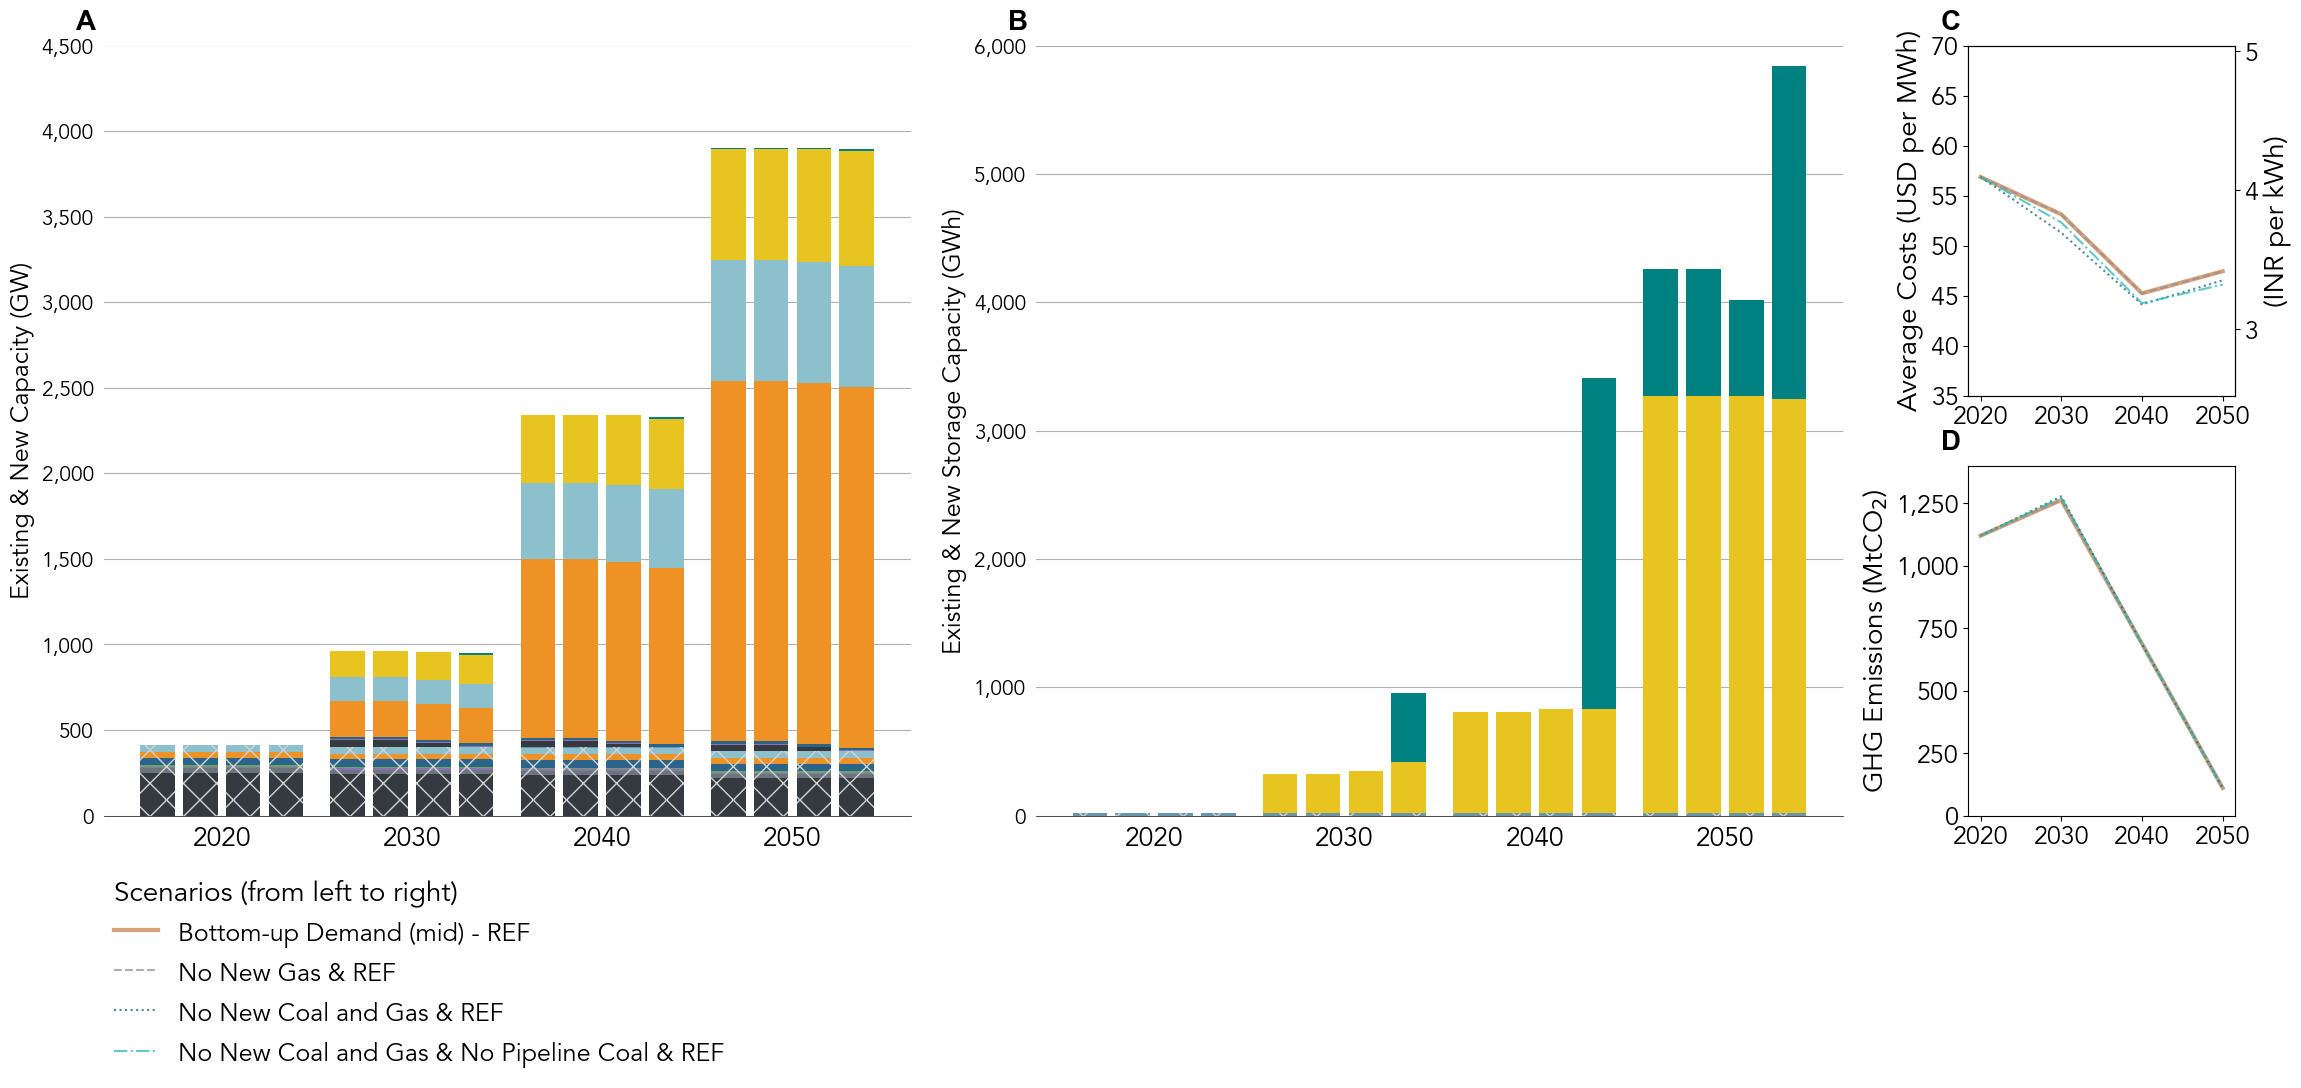

In [24]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize  = 20, 
            weight    = "bold",
            va        = 'bottom',
            family    = 'Arial')

df_2_['scen_labels']['marker'] = None

_plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                ylabel     = 'Existing & New Capacity (GW)',
                                legend     = False,
                                y_lim_max  = 4500,
                                y_grid_inc = 500)

_plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                               ylabel     = 'Existing & New Storage Capacity (GWh)', 
                               legend     = False,
                               y_lim_max  = 6000,
                               y_grid_inc = 1000)

# Plot levelized cost of electricity for different scenarios
_plot_average_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                     y_min  = 35,
                     y_max  = 70,
                     legend = False)

# Plot GHG emissions for different scenarios
_plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                       y_min  = 0,
                       y_max  = 1400,
                       legend = False)

leg = _ax['D'].legend(title          = 'Scenarios (from left to right)',
                      handlelength   = 1.75,
                      loc            = (-7., -0.75),
                      frameon        = False,
                      title_fontsize = 20,
                      prop           = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-additional_5-capacity_summary.pdf',
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/SI-additional_5-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()

In [3]:
scen_group = 'additional_6'

df_1_ = {}
df_2_ = {}

df_1_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

df_1_['capacity'] = _load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = _load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = _group_capacity_technologies(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = _group_dispatch_technologies(df_1_['dispatch'], tech_labels_)

emission_      = _load_GHG_emissions(df_2_['scen_labels'])
cost_, demand_ = _load_cost(df_2_['scen_labels'])
clean_         = _load_clean_energy(df_2_['scen_labels'])

df_2_['emissions']                    = _group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = _group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
df_2_['clean_energy']                 = _group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capcity exogeously
df_2_['system_cost']['fixed_cost'] += 5.79e9

# Save processed results in csv files
_save_group_csv(df_1_['capacity'], df_1_['scen_labels'], load_zones_, path_to_tables, 
                file_name = f'{scen_group}-grouped_capacity.csv')

_save_group_csv(df_1_['dispatch'], df_1_['scen_labels'], load_zones_, path_to_tables, 
                file_name = f'{scen_group}-grouped_dispatch.csv')

_save_summary_csv(df_2_, path_to_tables, file_name = f'{scen_group}' + '-{}.csv')

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/demand
VREmid_STmid_CONVmid_H2_NoNewGas_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_NoNewGas_NoCoalPipeline_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_NoNewGas_NoCoalPipepile_NoNewCoal_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid all /Users/Guille/Desktop/india_power/scenarios/demand
VREmid_STmid_CONVmid_H2_NoNewGas_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid all /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_NoNewGas_NoCoalPipeline_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid all /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_NoNewGas_NoCoalPipepile_NoNewCoal_RES_8PRM_CC_50RPS_9

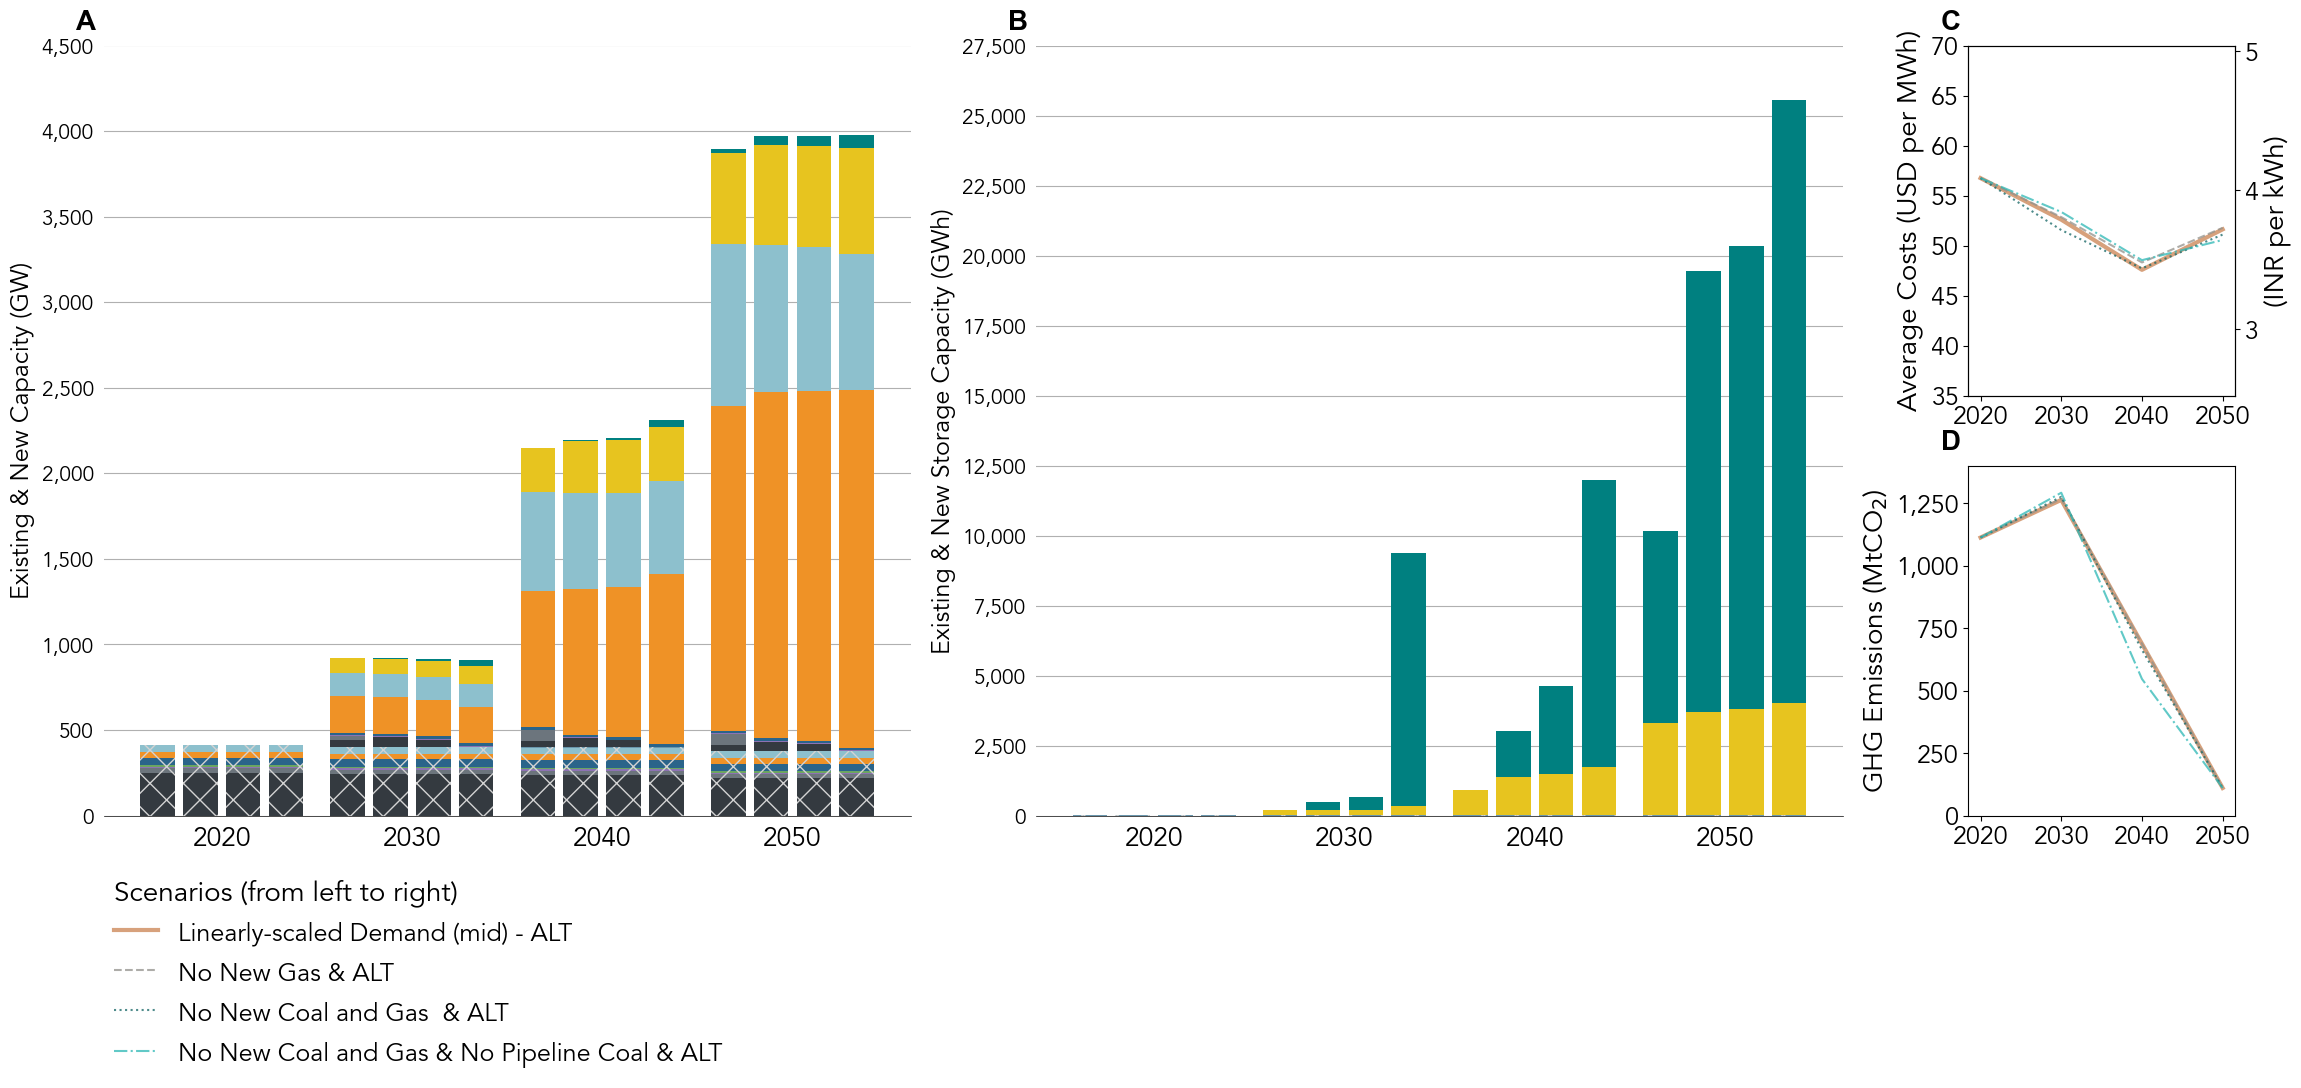

In [5]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize  = 20, 
            weight    = "bold",
            va        = 'bottom',
            family    = 'Arial')

df_2_['scen_labels']['marker'] = None

_plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                ylabel     = 'Existing & New Capacity (GW)',
                                legend     = False,
                                y_lim_max  = 4500,
                                y_grid_inc = 500)

_plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                               ylabel     = 'Existing & New Storage Capacity (GWh)', 
                               legend     = False,
                               y_lim_max  = 26000,
                               y_grid_inc = 2500)

# Plot average cost of electricity for different scenarios
_plot_average_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                     y_min  = 35,
                     y_max  = 70,
                     legend = False)

# Plot GHG emissions for different scenarios
_plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                       y_min  = 0,
                       y_max  = 1400,
                       legend = False)

leg = _ax['D'].legend(title          = 'Scenarios (from left to right)',
                      handlelength   = 1.75,
                      loc            = (-7., -0.75),
                      frameon        = False,
                      title_fontsize = 20,
                      prop           = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-additional_6-capacity_summary.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/SI-additional_6-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [ ]:
scen_group = 'ra_1'

df_1_ = {}
df_2_ = {}

df_1_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

df_1_['capacity'] = _load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = _load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = _group_capacity_technologies(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = _group_dispatch_technologies(df_1_['dispatch'], tech_labels_)

emission_      = _load_GHG_emissions(df_2_['scen_labels'])
cost_, demand_ = _load_cost(df_2_['scen_labels'])
clean_         = _load_clean_energy(df_2_['scen_labels'])

df_2_['emissions']                    = _group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = _group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
df_2_['clean_energy']                 = _group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capcity exogeously
df_2_['system_cost']['fixed_cost'] += 5.79e9

# Save processed results in csv files
_save_group_csv(df_1_['capacity'], df_1_['scen_labels'], load_zones_, path_to_tables, 
                file_name = f'{scen_group}-grouped_capacity.csv')

_save_group_csv(df_1_['dispatch'], df_1_['scen_labels'], load_zones_, path_to_tables, 
                file_name = f'{scen_group}-grouped_dispatch.csv')

_save_summary_csv(df_2_, path_to_tables, file_name = f'{scen_group}' + '-{}.csv')

In [ ]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize  = 20, 
            weight    = "bold",
            va        = 'bottom',
            family    = 'Arial')

df_2_['scen_labels']['marker'] = None

_plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                ylabel     = 'Existing & New Capacity (GW)',
                                legend     = False,
                                y_lim_max  = 2500,
                                y_grid_inc = 250)

_plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                               ylabel     = 'Existing & New Storage Capacity (GWh)', 
                               legend     = False,
                               y_lim_max  = 1000,
                               y_grid_inc = 125)

# Plot levelized cost of electricity for different scenarios
_plot_levelized_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                     y_min  = 40,
                     y_max  = 60,
                     legend = False)

# Plot GHG emissions for different scenarios
_plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                       y_min  = 0,
                       y_max  = 1400,
                       legend = False)

leg = _ax['D'].legend(title          = 'Scenarios (from left to right)',
                      handlelength   = 1.75,
                      loc            = (-7., -0.5),
                      frameon        = False,
                      title_fontsize = 20,
                      prop           = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/RA-NoCAP-capacity_summary.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + '/RA-NoCAP-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [ ]:
scen_group = 'ra_2'

df_1_ = {}
df_2_ = {}

df_1_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + f'/{scen_group}-scenario_labels.csv') 

df_1_['capacity'] = _load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = _load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = _group_capacity_technologies(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = _group_dispatch_technologies(df_1_['dispatch'], tech_labels_)

emission_      = _load_GHG_emissions(df_2_['scen_labels'])
cost_, demand_ = _load_cost(df_2_['scen_labels'])
clean_         = _load_clean_energy(df_2_['scen_labels'])

df_2_['emissions']                    = _group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = _group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
df_2_['clean_energy']                 = _group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capcity exogeously
df_2_['system_cost']['fixed_cost'] += 5.79e9

# Save processed results in csv files
_save_group_csv(df_1_['capacity'], df_1_['scen_labels'], load_zones_, path_to_tables, 
                file_name = f'{scen_group}-grouped_capacity.csv')

_save_group_csv(df_1_['dispatch'], df_1_['scen_labels'], load_zones_, path_to_tables, 
                file_name = f'{scen_group}-grouped_dispatch.csv')

_save_summary_csv(df_2_, path_to_tables, file_name = f'{scen_group}' + '-{}.csv')

In [ ]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize  = 20, 
            weight    = "bold",
            va        = 'bottom',
            family    = 'Arial')

df_2_['scen_labels']['marker'] = None

_plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                ylabel     = 'Existing & New Capacity (GW)',
                                legend     = False,
                                y_lim_max  = 2500,
                                y_grid_inc = 250)

_plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                               ylabel     = 'Existing & New Storage Capacity (GWh)', 
                               legend     = False,
                               y_lim_max  = 1000,
                               y_grid_inc = 125)

# Plot levelized cost of electricity for different scenarios
_plot_levelized_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                     y_min  = 40,
                     y_max  = 60,
                     legend = False)

# Plot GHG emissions for different scenarios
_plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                       y_min  = 0,
                       y_max  = 1400,
                       legend = False)

leg = _ax['D'].legend(title          = 'Scenarios (from left to right)',
                      handlelength   = 1.75,
                      loc            = (-7., -0.75),
                      frameon        = False,
                      title_fontsize = 20,
                      prop           = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/RA-90CAP-capacity_summary.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + '/RA-90CAP-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [16]:
scen_csv_file = 'ra_3-scenario_labels.csv'

df_1_ = {}
df_1_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

df_1_['capacity'] = _load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = _load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = _group_capacity_technologies(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = _group_dispatch_technologies(df_1_['dispatch'], tech_labels_)

df_2_ = {}
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

emission_      = _load_GHG_emissions(df_2_['scen_labels'])
cost_, demand_ = _load_cost(df_2_['scen_labels'])

df_2_['emissions'] = _group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = _group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capcity exogeously
df_2_['system_cost']['fixed_cost'] += 5.79e9

RA2040_VREmid_STmid_CONVmid_H2_RES_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_4PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_12PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_50RPS_90LinCAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_4PRM_CC_50RPS_90LinCAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90LinCAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_12PRM_CC_50RPS_90LinCAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_50RPS_500GW_PIERmid all /Users/Guille/Desktop/india_power/scena

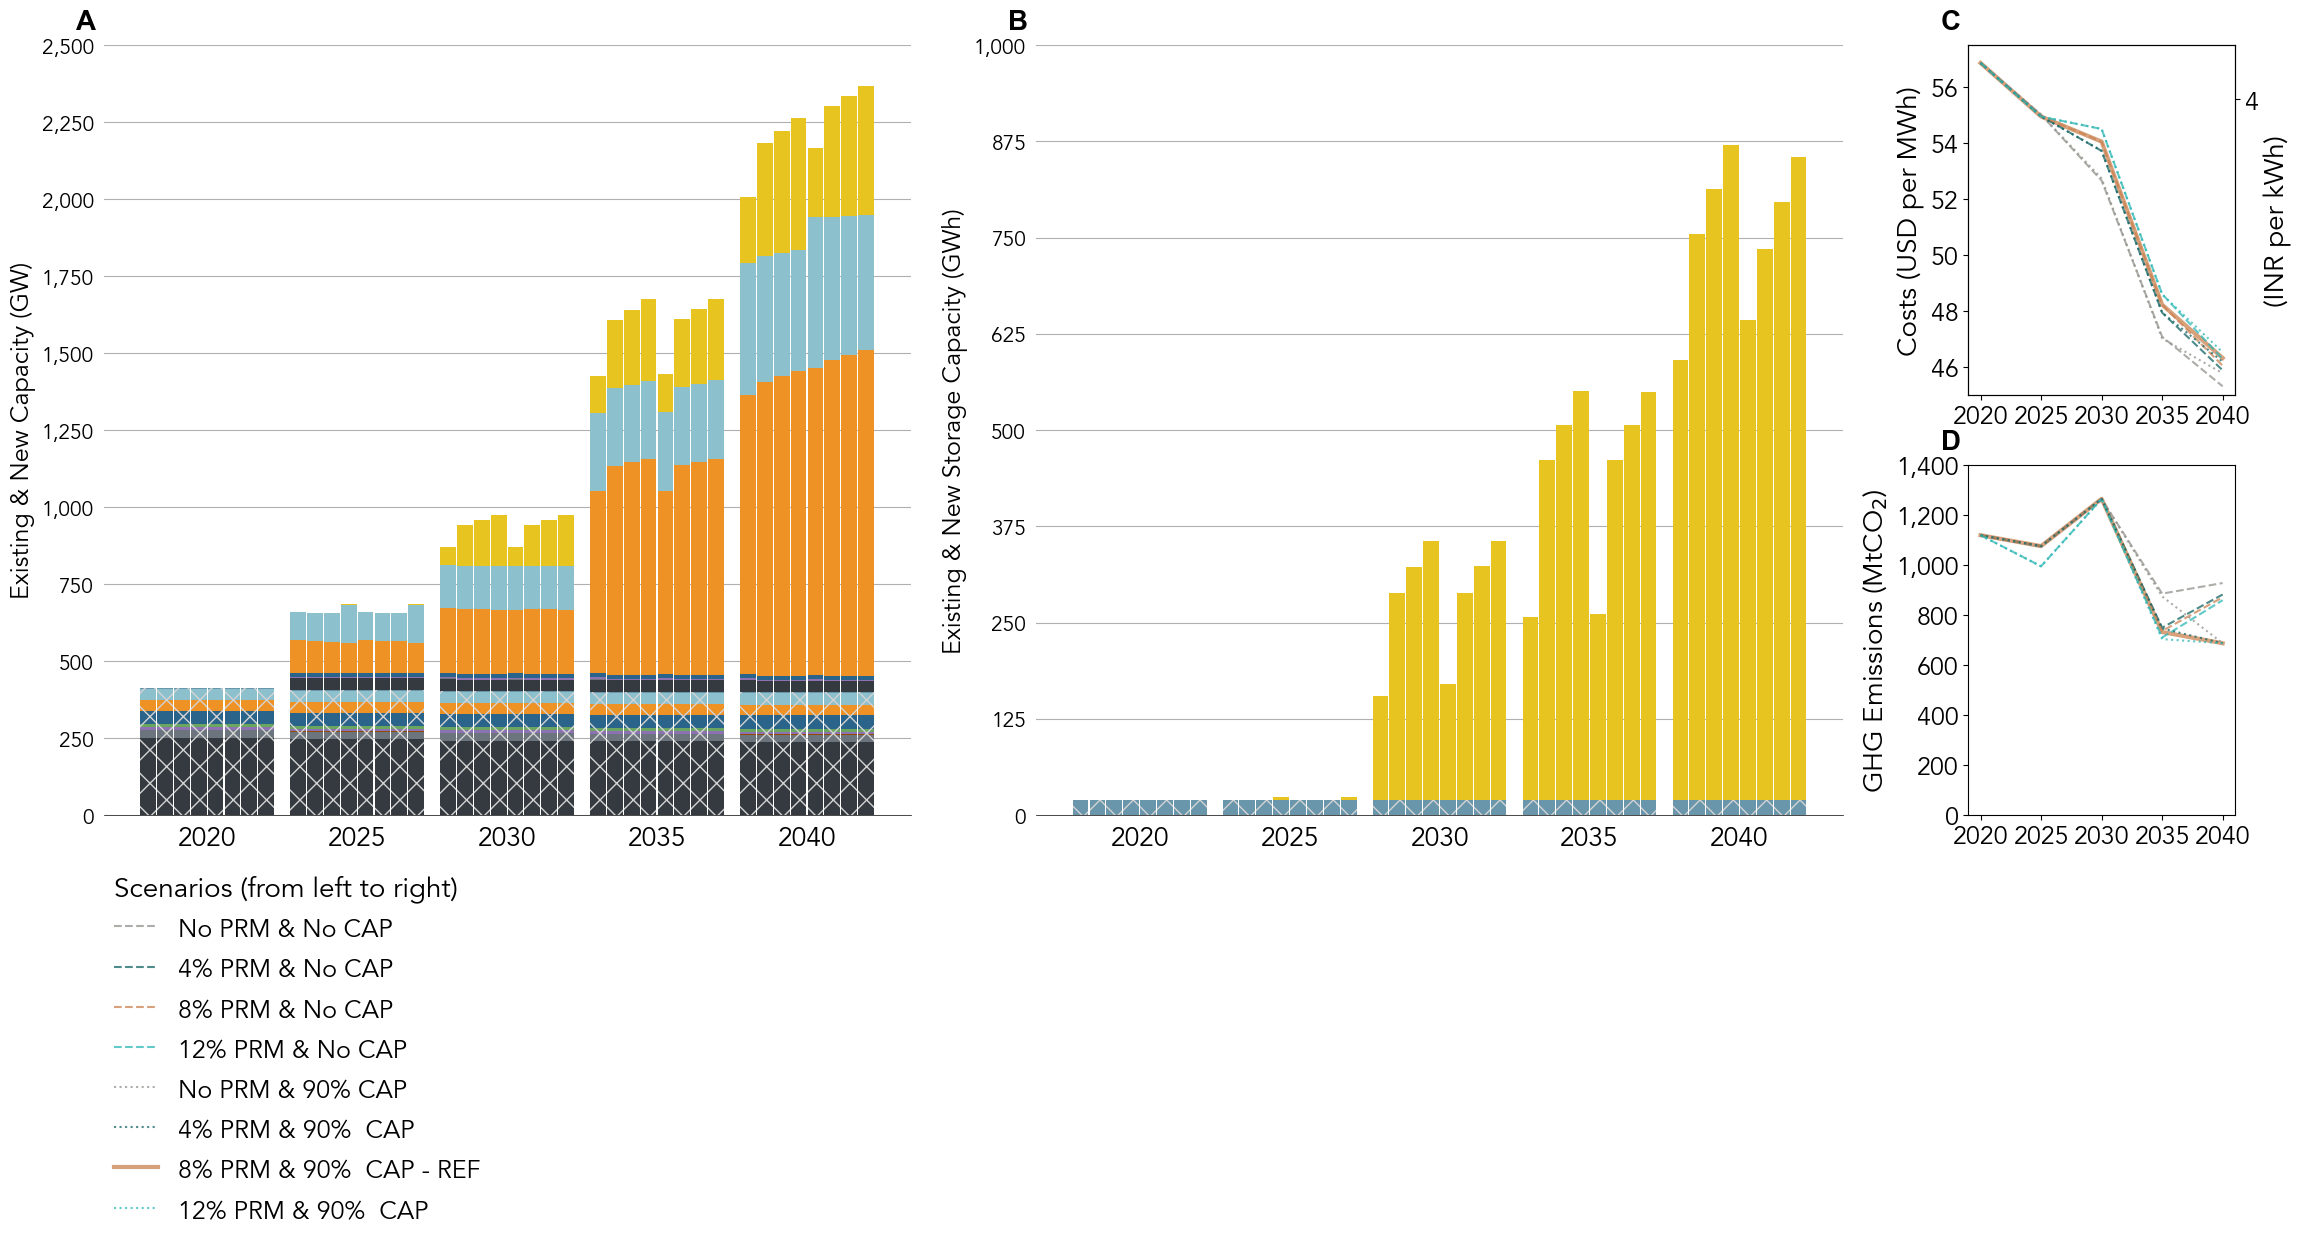

In [22]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize  = 20, 
            weight    = "bold",
            va        = 'bottom',
            family    = 'Arial')

df_2_['scen_labels']['marker'] = None

_plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                ylabel     = 'Existing & New Capacity (GW)',
                                legend     = False,
                                y_lim_max  = 2500,
                                y_grid_inc = 250)

_plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                               ylabel     = 'Existing & New Storage Capacity (GWh)', 
                               legend     = False,
                               y_lim_max  = 1000,
                               y_grid_inc = 125)

# Plot levelized cost of electricity for different scenarios
_plot_levelized_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                     y_min  = 45,
                     y_max  = 57.5,
                     legend = False)

# Plot GHG emissions for different scenarios
_plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                       y_min  = 0,
                       y_max  = 1400,
                       legend = False)

leg = _ax['D'].legend(title          = 'Scenarios (from left to right)',
                      handlelength   = 1.75,
                      loc            = (-7., -1.2),
                      frameon        = False,
                      title_fontsize = 20,
                      prop           = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/RA-No90CAP-capacity_summary.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + '/RA-No90CAP-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()